In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Load clean data
df = pd.read_csv("../data/processed/online_retail_featured.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Load forecast
forecast = pd.read_csv("../data/features/revenue_forecast.csv")

print("Data loaded!")
print("Main dataset:", df.shape)
print("Forecast:", forecast.shape)
print()
print("Columns:", list(df.columns))

Data loaded!
Main dataset: (779425, 16)
Forecast: (90, 4)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country', 'TotalRevenue', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'Quarter', 'IsWeekend']


In [2]:
# Calculate per product stats
product_stats = df.groupby(['StockCode', 'Description']).agg(
    Total_Quantity    = ('Quantity', 'sum'),
    Total_Revenue     = ('TotalRevenue', 'sum'),
    Avg_Daily_Qty     = ('Quantity', 'mean'),
    Std_Daily_Qty     = ('Quantity', 'std'),
    Num_Transactions  = ('Invoice', 'nunique'),
    Avg_Price         = ('Price', 'mean')
).reset_index()

# Remove system entries
product_stats = product_stats[
    ~product_stats['Description'].str.contains(
        'POSTAGE|MANUAL|DOTCOM|CRUK|AMAZONFEE|BANK|discount',
        case=False, na=False)
]

# Sort by revenue
product_stats = product_stats.sort_values(
    'Total_Revenue', ascending=False).reset_index(drop=True)

print("Product stats calculated!")
print("Total products:", len(product_stats))
print()
print("Top 10 products by revenue:")
print(product_stats[['Description','Total_Quantity',
                      'Total_Revenue','Avg_Price']].head(10))

Product stats calculated!
Total products: 5296

Top 10 products by revenue:
                          Description  Total_Quantity  Total_Revenue  \
0            REGENCY CAKESTAND 3 TIER           24124      277656.25   
1  WHITE HANGING HEART T-LIGHT HOLDER           91757      247048.01   
2         PAPER CRAFT , LITTLE BIRDIE           80995      168469.60   
3             JUMBO BAG RED RETROSPOT           74224      134307.44   
4       ASSORTED COLOUR BIRD ORNAMENT           78234      124351.86   
5                       PARTY BUNTING           23460      103283.38   
6      MEDIUM CERAMIC TOP STORAGE JAR           77916       81416.73   
7     PAPER CHAIN KIT 50'S CHRISTMAS            28380       76598.18   
8                       CHILLI LIGHTS           14843       69084.30   
9                JUMBO BAG STRAWBERRY           35842       64127.77   

   Avg_Price  
0  12.461649  
1   2.870666  
2   2.080000  
3   1.973870  
4   1.676152  
5   4.772912  
6   1.220303  
7   2.91960

In [3]:
# EOQ = Economic Order Quantity
# Formula: EOQ = sqrt(2 * D * S / H)
# D = Annual demand, S = Order cost, H = Holding cost

# Constants (industry standard assumptions)
ORDER_COST    = 50    # £50 per order placed
HOLDING_RATE  = 0.20  # 20% of item value per year to hold
LEAD_TIME     = 7     # 7 days from order to delivery
SERVICE_LEVEL = 1.65  # 95% service level (Z-score)
DAYS_IN_DATA  = 604   # days in our dataset

# Calculate daily demand per product
product_stats['Daily_Demand'] = (
    product_stats['Total_Quantity'] / DAYS_IN_DATA
)

# Annual demand
product_stats['Annual_Demand'] = product_stats['Daily_Demand'] * 365

# Holding cost per unit per year
product_stats['Holding_Cost'] = (
    product_stats['Avg_Price'] * HOLDING_RATE
)

# EOQ formula
product_stats['EOQ'] = np.sqrt(
    (2 * product_stats['Annual_Demand'] * ORDER_COST) /
    product_stats['Holding_Cost'].replace(0, 0.01)
).round(0)

# Safety stock = Z * std_demand * sqrt(lead_time)
product_stats['Safety_Stock'] = (
    SERVICE_LEVEL *
    product_stats['Std_Daily_Qty'].fillna(0) *
    np.sqrt(LEAD_TIME)
).round(0)

# Reorder Point = (Daily demand * Lead time) + Safety stock
product_stats['Reorder_Point'] = (
    product_stats['Daily_Demand'] * LEAD_TIME +
    product_stats['Safety_Stock']
).round(0)

print("Inventory calculations complete!")
print()
print("Top 10 products — Inventory Plan:")
cols = ['Description','Daily_Demand','EOQ',
        'Safety_Stock','Reorder_Point']
print(product_stats[cols].head(10).to_string(index=False))

Inventory calculations complete!

Top 10 products — Inventory Plan:
                       Description  Daily_Demand    EOQ  Safety_Stock  Reorder_Point
          REGENCY CAKESTAND 3 TIER     39.940397  765.0          75.0          355.0
WHITE HANGING HEART T-LIGHT HOLDER    151.915563 3108.0         262.0         1325.0
       PAPER CRAFT , LITTLE BIRDIE    134.097682 3430.0           0.0          939.0
           JUMBO BAG RED RETROSPOT    122.887417 3371.0         273.0         1133.0
     ASSORTED COLOUR BIRD ORNAMENT    129.526490 3755.0         431.0         1338.0
                     PARTY BUNTING     38.841060 1219.0          88.0          360.0
    MEDIUM CERAMIC TOP STORAGE JAR    129.000000 4392.0       23019.0        23922.0
   PAPER CHAIN KIT 50'S CHRISTMAS      46.986755 1714.0         211.0          540.0
                     CHILLI LIGHTS     24.574503  934.0         161.0          333.0
              JUMBO BAG STRAWBERRY     59.341060 2352.0         233.0          648

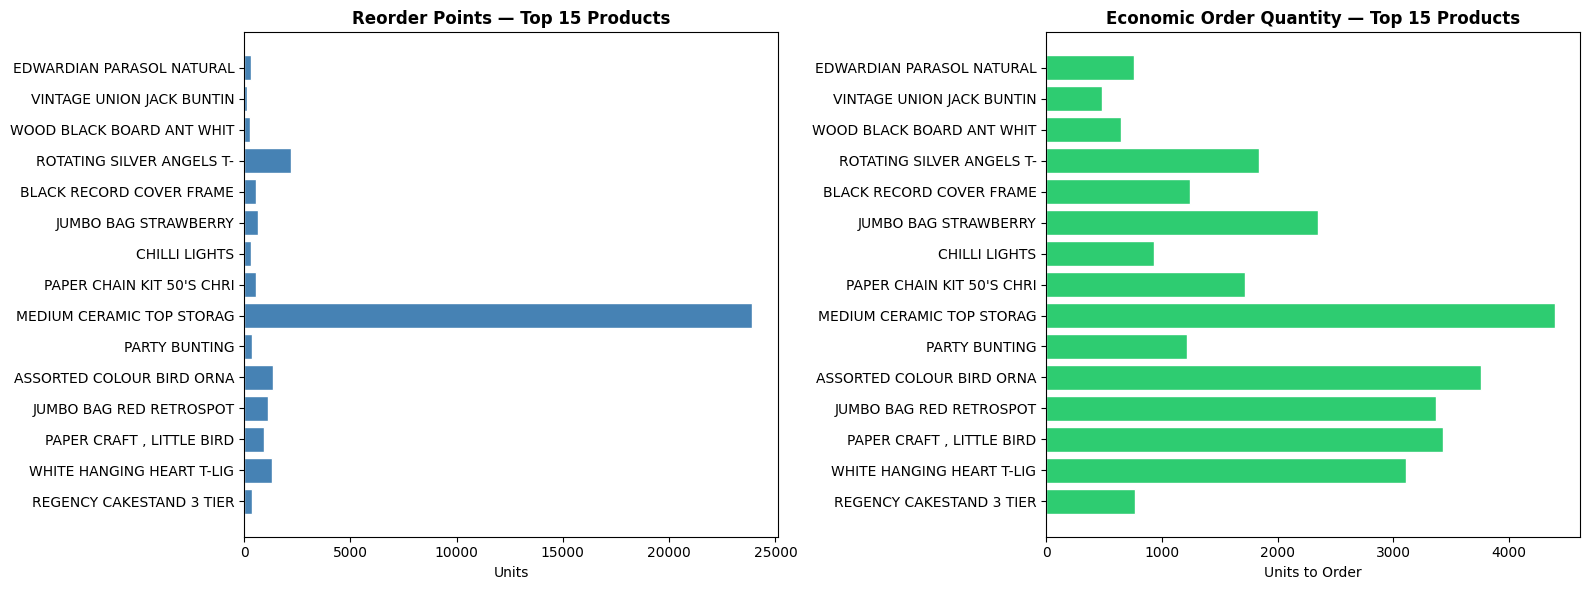

Inventory plot saved!


In [4]:
# Plot top 15 products — Reorder Points vs Safety Stock
top15 = product_stats.head(15).copy()
top15['Short_Name'] = top15['Description'].str[:25]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Reorder points
axes[0].barh(top15['Short_Name'], top15['Reorder_Point'],
             color='steelblue', edgecolor='white')
axes[0].set_title('Reorder Points — Top 15 Products',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Units')

# EOQ
axes[1].barh(top15['Short_Name'], top15['EOQ'],
             color='#2ecc71', edgecolor='white')
axes[1].set_title('Economic Order Quantity — Top 15 Products',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Units to Order')

plt.tight_layout()
plt.savefig('../reports/plots/inventory_plan.png', dpi=150)
plt.show()
print("Inventory plot saved!")

In [5]:
# Save inventory plan
inventory_plan = product_stats[[
    'StockCode', 'Description', 'Daily_Demand',
    'Annual_Demand', 'Avg_Price', 'EOQ',
    'Safety_Stock', 'Reorder_Point', 'Total_Revenue'
]].copy()

inventory_plan.to_csv("../data/features/inventory_plan.csv", index=False)

print("="*55)
print("   INVENTORY OPTIMIZATION COMPLETE")
print("="*55)
print(f"  Products analysed:        {len(inventory_plan):,}")
print(f"  Method:                   EOQ Model")
print()
print("  Assumptions:")
print(f"  Order cost:               £{ORDER_COST}/order")
print(f"  Holding rate:             {HOLDING_RATE*100}% of item value/year")
print(f"  Lead time:                {LEAD_TIME} days")
print(f"  Service level:            95% (Z = {SERVICE_LEVEL})")
print()
print("  Top 3 products to prioritize:")
for i, row in product_stats.head(3).iterrows():
    print(f"  {i+1}. {row['Description'][:35]}")
    print(f"     Reorder at: {row['Reorder_Point']:.0f} units | Order: {row['EOQ']:.0f} units")
print()
print("  File saved: data/features/inventory_plan.csv")
print("="*55)

   INVENTORY OPTIMIZATION COMPLETE
  Products analysed:        5,296
  Method:                   EOQ Model

  Assumptions:
  Order cost:               £50/order
  Holding rate:             20.0% of item value/year
  Lead time:                7 days
  Service level:            95% (Z = 1.65)

  Top 3 products to prioritize:
  1. REGENCY CAKESTAND 3 TIER
     Reorder at: 355 units | Order: 765 units
  2. WHITE HANGING HEART T-LIGHT HOLDER
     Reorder at: 1325 units | Order: 3108 units
  3. PAPER CRAFT , LITTLE BIRDIE
     Reorder at: 939 units | Order: 3430 units

  File saved: data/features/inventory_plan.csv
